# Regresion Lineal II. Descenso de gradiente 


La ecuación normal tiene grandes ventajas a la hora de calcular los coeficientes de la *Regresión Lineal*:
* La ecuación normal proporciona una solución exacta a la regresión lineal al minimizar directamente la función de error cuadrático medio. Esto es posible porque deriva directamente de la fórmula cerrada de los mínimos cuadrados.
* La ecuación normal es muy fácil de implementar cuando el conjunto de datos tiene un número pequeño o moderado de características (es decir, el número de columnas de tu matriz de entrada). Solo necesitas multiplicar matrices y tomar la inversa de una matriz.
* Dado que la ecuación normal calcula directamente los coeficientes que minimizan el error, no hay riesgo de que el modelo no converja.

Sin embargo involucra dos cálculos problematicos:
* $X^TX$ Puede resultar en una matriz singular si los datos de entrada están próximos entre sí. La inversión de matrices puede ser numéricamente inestable si la matriz que se invierte está mal condicionada (es decir, si tiene determinante cercano a cero).
* $(X^TX)^{-1}$ La ecuación normal implica invertir una matriz, lo cual tiene una complejidad computacional de $\mathcal{O}(n^3)$, donde $n$ es el número de características o columnas en tu matriz de entrada. Esto hace que sea computacionalmente costosa para conjuntos de datos con muchas características.

En esos casos es recomendable el empleo de técnicas iterativas como el **Descenso de Gradiente**.

El descenso de gradiente es un método de optimización ampliamente utilizado en el campo del aprendizaje automático y la estadística para minimizar funciones de coste o error.

El descenso de gradiente es un algoritmo que busca encontrar el valor óptimo de los parámetros o pesos, $\Theta$, que minimicen la función de coste $J(\Theta)$. El propósito es ajustar los parámetros del modelo para que las predicciones se aproximen lo mejor posible a los valores reales.

La idea fundamental detrás del descenso de gradiente es simple: si deseamos minimizar $J(\Theta)$, comenzamos con un valor inicial para $\Theta$, elegido de forma aleatoria o predefinida. 

Desde este punto de partida, el algoritmo utiliza el gradiente $\nabla_{\Theta} J(\Theta)$, que indica la dirección de mayor aumento de la función de coste, para decidir hacia dónde moverse.

Sin embargo, dado que el objetivo es minimizar $J(\Theta)$, no seguimos la dirección del gradiente. En lugar de eso, nos desplazamos en sentido opuesto al gradiente, es decir, en la dirección que disminuye más rápidamente la función de coste. Este proceso de ajuste continuo de los parámetros se repite hasta que alcanzamos un punto donde el gradiente es cercano a cero, lo que indica que hemos llegado a un mínimo (local o global), ya que en un mínimo el gradiente es cero.

<div style="display: flex; align-items: center;">

<div style="margin-right: 20px;">

Algoritmo:

* Partimos de $\Theta^0$ elegido aleatoriamente y calculamos $J(\Theta^0)$
* $\Theta^1 = \Theta^0 - \alpha \nabla_{\Theta} J(\Theta^0)$
* $\Theta^2 = \Theta^1 - \alpha \nabla_{\Theta} J(\Theta^1)$
* ...
* $\Theta^{k+1} = \Theta^k - \alpha \nabla_{\Theta} J(\Theta^k)$
</div>
<div>

</div>
</div>


En cada paso evaluamos $J(\Theta^k)$. El algoritmo se detiene cuando $J(\Theta^k)$ sea menor que una tolerancia dada o se hayan alcanzado el número máximo de iteraciones para el proceso.

En el caso de que estemos utilizando el MSE como función de coste, la convexidad de $J(\Theta)$ y el hecho de que $\nabla_{\Theta} J(\Theta)$ es [Lipschitz](https://web.stanford.edu/~boyd/cvxbook/bv_cvxbook.pdf) hacen que la convergencia esté garantizada.




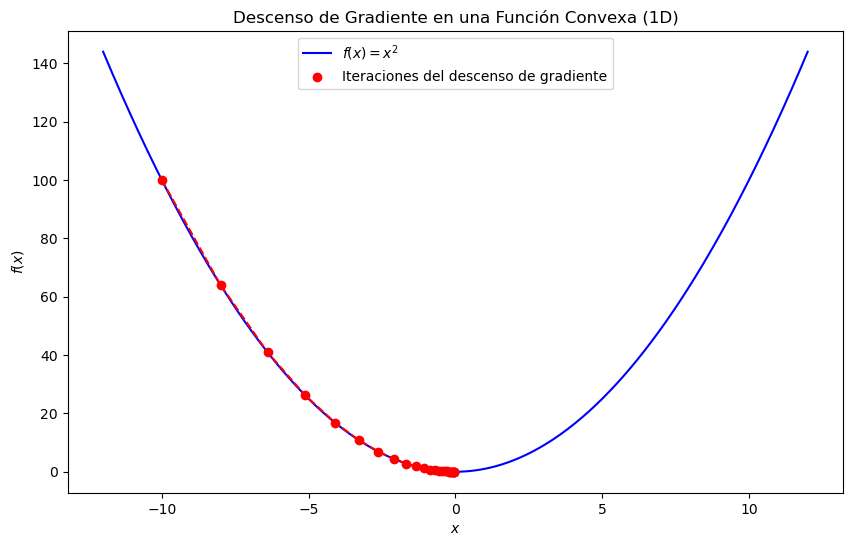

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

images_path = '.\Imagenes'
if not os.path.isdir(images_path):
    os.makedirs(images_path)

# Definición de la función convexa f(x) = x^2 y su derivada
def f(x):
    return x**2

def f_prime(x):
    return 2*x

# Algoritmo de descenso de gradiente
def gradient_descent(start_x, learning_rate, num_iterations):
    x = start_x
    path = [x]  # Guardar el camino que sigue el descenso de gradiente
    for _ in range(num_iterations):
        grad = f_prime(x)
        x = x - learning_rate * grad
        path.append(x)
    return np.array(path)

# Parámetros del algoritmo
start_x = -10  # Punto inicial
learning_rate = 0.1  # Tamaño del paso
num_iterations = 25  # Número de iteraciones

# Ejecutar el descenso de gradiente
path = gradient_descent(start_x, learning_rate, num_iterations)

# Crear un gráfico de la función f(x)
x_vals = np.linspace(-12, 12, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x) = x^2$', color='blue')

# Graficar los puntos que sigue el descenso de gradiente
plt.scatter(path, f(path), color='red', zorder=5, label='Iteraciones del descenso de gradiente')
plt.plot(path, f(path), color='red', linestyle='dashed', zorder=5)

# Añadir etiquetas y título
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.title('Descenso de Gradiente en una Función Convexa (1D)')

# Añadir la leyenda
plt.legend()

# Mostrar el gráfico
plt.savefig(os.path.join(images_path, "GD_1"))
plt.show()


Podríamos sintetizar el algoritmo con la expresión:

$$
\boxed{\Theta^{k+1} = \Theta^k  - \alpha \nabla_{\Theta}J(\Theta^k)}
$$

La tasa de aprendizaje $\alpha$ es un parámetro importante. Define el tamaño del paso que da el algoritmo en cada iteración. En funciones de coste que no aseguren la convergencia puede ocurrir que si $\alpha$ es:

* Demasiado grande: El algoritmo podría saltarse el mínimo y no converger, o incluso divergir.
* Demasiado pequeña: El algoritmo tardará mucho en converger y puede quedar atrapado en mínimos locales.

Juega con el parametro `learning_rate` en las dos celdas siguientes para ver su efecto.

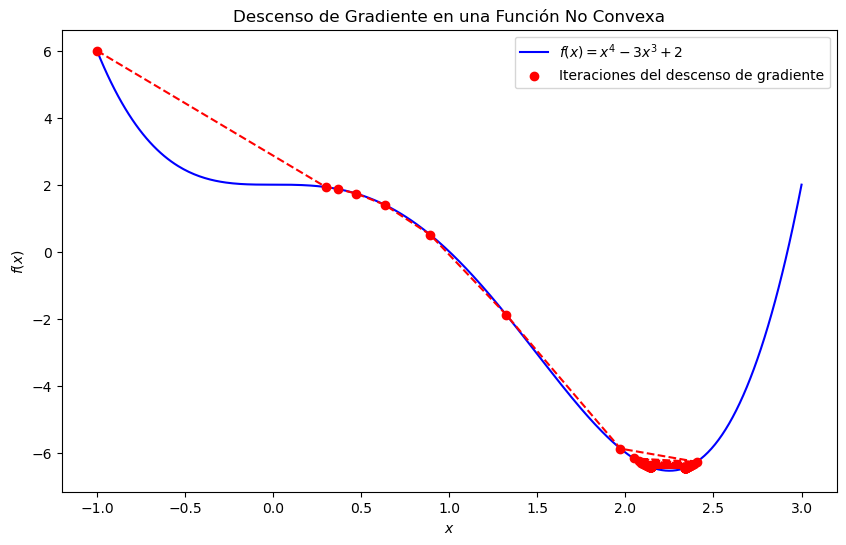

In [5]:
def f(x):
    return x**4 - 3*x**3 + 2

def f_prime(x):
    return 4*x**3 - 9*x**2

# Parámetros del algoritmo
start_x = -1  # Punto inicial (puedes cambiarlo para ver diferentes resultados)
learning_rate = 0.1
num_iterations = 100

# Ejecutar el descenso de gradiente
path = gradient_descent(start_x, learning_rate, num_iterations)

# Crear un gráfico de la función f(x)
x_vals = np.linspace(-1, 3, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x) = x^4 - 3x^3 + 2$', color='blue')

# Graficar los puntos que sigue el descenso de gradiente
plt.scatter(path, f(path), color='red', zorder=5, label='Iteraciones del descenso de gradiente')
plt.plot(path, f(path), color='red', linestyle='dashed', zorder=5)

# Añadir etiquetas y título
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.title('Descenso de Gradiente en una Función No Convexa')

# Añadir la leyenda
plt.legend()

# Mostrar el gráfico
plt.savefig(os.path.join(images_path, "GD_2"))
plt.show()

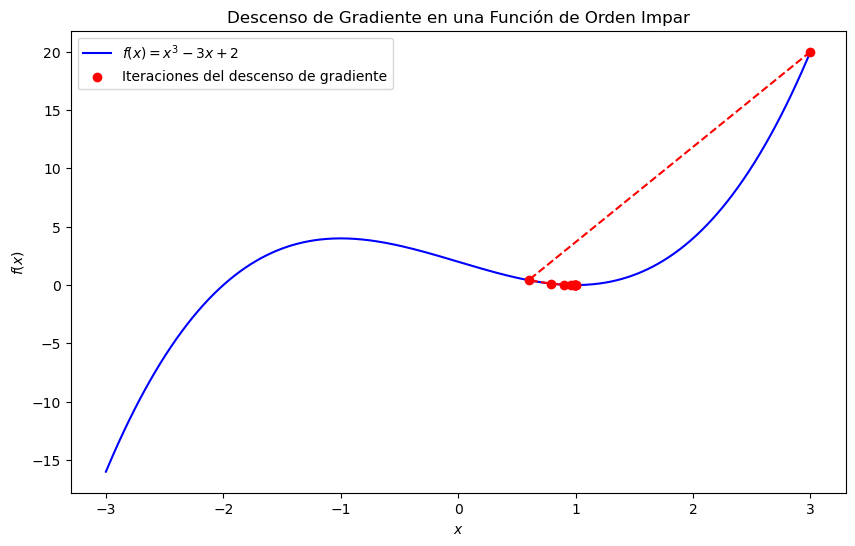

In [7]:
# Definición de la función f(x) = x^3 - 3x + 2 y su derivada
def f(x):
    return x**3 - 3*x + 2

def f_prime(x):
    return 3*x**2 - 3

# Parámetros del algoritmo
start_x = 3  # Punto inicial
learning_rate = 0.1
num_iterations = 10

# Ejecutar el descenso de gradiente
path = gradient_descent(start_x, learning_rate, num_iterations)

# Crear un gráfico de la función f(x)
x_vals = np.linspace(-3, 3, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=r'$f(x) = x^3 - 3x + 2$', color='blue')

# Graficar los puntos que sigue el descenso de gradiente
plt.scatter(path, f(path), color='red', zorder=5, label='Iteraciones del descenso de gradiente')
plt.plot(path, f(path), color='red', linestyle='dashed', zorder=5)

# Añadir etiquetas y título
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.title('Descenso de Gradiente en una Función de Orden Impar')

# Añadir la leyenda
plt.legend()

# Mostrar el gráfico
plt.savefig(os.path.join(images_path, "GD_3"))
plt.show()

### Caso con varias variables predictoras.

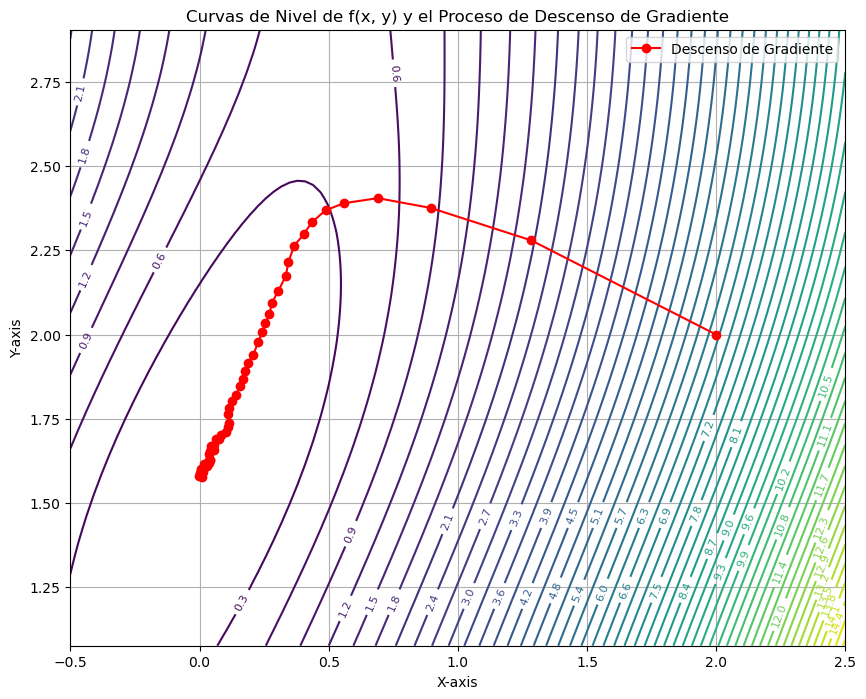

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de la función f(x, y) y su gradiente
def f(x, y):
    return x**2 + (x+np.cos(y))**2

def gradient(x, y):
    df_dx = 2*(x + (x+np.cos(y)))
    df_dy = -2*(x+np.cos(y)) * np.sin(y)
    return np.array([df_dx, df_dy])

# Algoritmo de descenso de gradiente con oscilaciones en el gradiente
def gradient_descent_with_oscillation(start, learning_rate, num_iterations):
    point = np.array(start)
    path = [point.copy()]
    for _ in range(num_iterations):
        grad = gradient(point[0], point[1])
        # Oscilación aleatoria
        oscillation = np.random.uniform(-0.1, 0.1, size=2)  
        point = point - learning_rate * (grad + oscillation)
        path.append(point.copy())
    return np.array(path)

# Parámetros del algoritmo
start = [2.0, 2.0]  # Punto inicial
learning_rate = 0.1
num_iterations = 50

# Ejecutar el descenso de gradiente
path = gradient_descent_with_oscillation(start, learning_rate, num_iterations)

# Crear un gráfico de curvas de nivel
x_vals = np.linspace(min(path[:,0])-0.5, max(path[:,0])+0.5, 100)
y_vals = np.linspace(min(path[:,1])-0.5, max(path[:,1])+0.5, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

plt.figure(figsize=(10, 8))
contour = plt.contour(X, Y, Z, levels=50, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)

# Graficar el camino del descenso de gradiente
plt.plot(path[:, 0], path[:, 1], color='red', marker='o', label='Descenso de Gradiente')
plt.title('Curvas de Nivel de f(x, y) y el Proceso de Descenso de Gradiente')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.savefig(os.path.join(images_path, "GD_2D_1"))
plt.show()



 


De nuevo consideremos como entrada un vector con $n+1$ componentes $\boldsymbol{x}^j = (x_0^j,x_1^j,x_2^j, \dots, x_n^j)$ siendo $x_i^j$ el valor de la característica $i$ del elemento (registro) $j$ de la muestra de datos. Recuerda que $x_0^j = 1$ de manera que el vector tiene $n$ características.
Además $\Theta = (\theta_0,\theta_1, \dots,\theta_n)$ es el vector de pesos que queremos determinar, y:
$$ \hat{y}^j = h_\Theta(\boldsymbol{x^j})= \theta_0 + \theta_1 x^j_1 + \theta_2 x^j_2 + \dots +\theta_n x^j_n $$
es la predicción para cada uno de los $m$ registros $\boldsymbol{x^j}$ que intentamos sea lo más parecida posible al valor real $y^j$.
La función de error se define como: 
$$
J(\Theta) = \dfrac{1}{m} \sum_{j=1}^m (h_\Theta(\boldsymbol{x^j})-y^j)^2
$$

Matricialmente, recordamos que:
$$
\boldsymbol{X} = \begin{pmatrix}
1 & x_1^1 & x_2^1 & \dots & x_n^1\\
1 & x_1^2 & x_2^2 & \dots & x_n^2\\
\vdots & \vdots &  & \dots & \vdots\\
1 & x_1^m & x_2^m & \dots & x_n^m
\end{pmatrix}
\hspace{1.0cm}
\boldsymbol{X} \in \cal{M}^{m\times(n+1)}(\cal{R})
$$
$$\Theta = \begin{pmatrix}
\theta_0 \\
\theta_1 \\
\vdots\\
\theta_n
\end{pmatrix}
\hspace{0.5cm}
Y = 
\begin{pmatrix}
y^1\\
y^2\\
\vdots \\
y^m
\end{pmatrix}
$$
y la aproximación
$$
\hat{Y} = h_\Theta(\boldsymbol{X})=\boldsymbol{X}\Theta = 
\begin{pmatrix}
\displaystyle\sum_{i=0}^n \theta_i x_i^1\\
\displaystyle\sum_{i=0}^n \theta_i x_i^2\\
\vdots \\
\displaystyle\sum_{i=0}^n \theta_i x_i^m
\end{pmatrix}=
\begin{pmatrix}
\hat{y}^1\\
\hat{y}^2\\
\vdots \\
\hat{y}^m
\end{pmatrix} 
$$

#### Ecuación general del método de Descenso de Gradiente.

La ecuación que vimos anteriormente se vectoriza para el caso multivariable:

$$
\begin{pmatrix}
\displaystyle\theta_0 \\
\\
\displaystyle\theta_1 \\ 
\\
\vdots \\ 
\\
\displaystyle\theta_n
\end{pmatrix}^{k+1} =
\begin{pmatrix}
\displaystyle\theta_0 \\ 
\\
\displaystyle\theta_1 \\ 
\\
\vdots \\ 
\\
\displaystyle\theta_n
\end{pmatrix}^{k}
-
\alpha 
\begin{pmatrix}
\displaystyle\dfrac{\partial J (\Theta^k)}{\partial \theta_0} \\ 
\displaystyle\dfrac{\partial J (\Theta^k)}{\partial \theta_1} \\ 
\vdots \\ 
\displaystyle\dfrac{\partial J (\Theta^k)}{\partial \theta_n}
\end{pmatrix}
$$

Si derivamos la función de error respecto de una compenente genérica del vector de pesos $\Theta$ tenemos:
$$
\dfrac{\partial}{\partial \theta_i}J(\Theta^k) = \dfrac{\partial}{\partial \theta_i} \left( \dfrac{1}{m} \sum_{j=1}^m \left( h_{\Theta^k}(\boldsymbol{x^j})-y^j \right)^2   \right) =
$$

$$
 =\dfrac{1}{m} \displaystyle\sum_{j=1}^m  \dfrac{\partial}{\partial \theta_i} \left( \displaystyle\sum_{i=0}^n \theta_i^k x_i^j -y^j \right)^2   = \dfrac{2}{m}\displaystyle\sum_{j=1}^m \left( \displaystyle\sum_{i=0}^n \theta_i^k x_i^j -y^j \right)x_i^j =  \dfrac{2}{m} \sum_{j=1}^m (h_{\Theta^k}(\boldsymbol{x}^j)-y^j)x_i^j =  \dfrac{2}{m} \sum_{j=1}^m (\Theta^k \boldsymbol{x}^j-y^j)x_i^j
$$

De modo que podemos escribir el gradiente de forma vectorial como:

$$
\nabla_\Theta J(\Theta^k) = \dfrac{2}{m}
\begin{pmatrix}
\displaystyle\sum_{j=1}^m (\Theta^k \boldsymbol{x}^j-y^j)x_0^j \\ 
\displaystyle\sum_{j=1}^m (\Theta^k \boldsymbol{x}^j-y^j)x_1^j \\ 
\vdots \\ 
\displaystyle\sum_{j=1}^m (\Theta^k \boldsymbol{x}^j-y^j)x_n^j
\end{pmatrix}
= \dfrac{2}{m}\boldsymbol{X}^T(\boldsymbol{X}\Theta^k- Y)
$$

Para llegar a la expresión anterior basta recordar que:
$$
\boldsymbol{X}^T(\boldsymbol{X}\Theta^k- Y)= \begin{pmatrix}
1 & 1 & 1 & \dots & 1\\
x_1^1 & x_1^2 & x_1^3 & \dots & x_1^m\\
\vdots & \vdots &  & \dots & \vdots\\
x_n^1 & x_n^2 & x_n^3 & \dots & x_n^m
\end{pmatrix}
\begin{pmatrix}
\Theta^k\boldsymbol{x}^1-y^1\\
\Theta^k\boldsymbol{x}^2-y^2\\
\vdots \\
\Theta^k\boldsymbol{x}^m-y^m
\end{pmatrix} =
\begin{pmatrix}
\displaystyle\sum_{j=1}^m (\Theta^k \boldsymbol{x}^j-y^j)x_0^j\\
\displaystyle\sum_{j=1}^m (\Theta^k \boldsymbol{x}^j-y^j)x_1^j\\
\vdots \\
\displaystyle\sum_{j=1}^m (\Theta^k \boldsymbol{x}^j-y^j)x_n^j
\end{pmatrix}
$$


Por tanto la expresión matricial completa para el algoritmo de **Descenso de Gradiente** queda:
$$
\boxed{\Theta^{k+1} = \Theta^k - \alpha\left( \boldsymbol{X}^T\boldsymbol{X}\Theta^k  - \boldsymbol{X}^TY\right)  }
$$

donde hemos integrado en $\alpha$ el factor $\dfrac{2}{m}$.

## Implementación

In [2]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn import datasets
import seaborn as sns
import matplotlib.pyplot as plt

Empezaremos recuperando las dos funciones de la sección anterior:

* `normal_equations()`: A partir de los datos de entrada y las etiquetas calcula los coeficientes.
* `predicted()`: Una vez conocidos los coeficientes, devuelve la predicción dado un conjunto de datos de entrada.

y añadimos:

* `batch_gradient_descent(X,y,learning_rate = 0.0001, n_epochs = 100)` calcula los pesos $\Theta$ mediante **Descenso de Gradiente** dados:
    * `X`: Matriz de datos de entrada $\boldsymbol{X}$.
    * `y`: Vector de etiquetas $\bar{Y}$ para esos datos de entrada.
    * `learning_rate`: tasa de aprendizaje $\alpha$.
    * `n_epochs`: número de iteraciones del descenso de gradiente. Se suele llamar *épocas* o `epochs`.


In [7]:
def normal_equation(X,y):
    """
    X: el conjunto de datos de entrada en la matriz X(m,n)
        m: número de datos. 
        n: número de variables predictoras o atributos.
    y: Vector columna con las imagenes de los datos de entrada conocidas. 

    Resuelvo la ecuación normal (X^T)X Theta = (X^T)Y
    Return Theta: vector de coeficientes de la regresión lineal
    """
    n_samples, n_features = X.shape

    # El primer paso será añadir la columna de 1's a los datos
    X_1 = np.column_stack((np.ones(n_samples),X))

    # Construye la matriz (X^T)X y el vector (X^T)Y donde X es la matriz amplida con la columna de 1's
    A = X_1.T@X_1
    B = X_1.T@y

    # Resuelve el sistema lineal (X^T)X Theta = (X^T)Y usando la función adecuada de numpy

    Theta = np.linalg.solve(A,B)  

     
    return Theta

def predicted(X, Theta):
    """
    X: el conjunto de datos de entrada en la matriz X(m,n)
        m: número de datos. 
        n: número de variables predictoras o atributos.
    Theta: vector de coeficientes Theta que devuelve la ecuación normal

    Return Y = X Theta
    """
    n_samples, n_features = X.shape
    # El primer paso será añadir la columna de 1's a los datos
    X_1 = np.column_stack((np.ones(n_samples),X))

    # Calcula el vector de predicciones asociado a los datos de entrada Y=X Theta siendo X es la matriz amplida con la columna de 1's
    Y = X_1@Theta

    return  Y

def batch_gradient_descent(X,y,learning_rate = 0.0001, n_epochs = 100):
    """
    X: el conjunto de datos de entrada en la matriz X(m,n)
        m: número de datos. 
        n: número de variables predictoras o atributos.
    y: Vector con las imagenes de los datos de entrada conocidas.
    learning_rate: Tasa de aprendizaje. Por defecto 0.0001
    n_iters: Numero de iteraciones o épocas del proceso iterativo. Por defecto 100 

    Evaluo n_iters:
        Theta^k+1 = Theta^k - learning_rate (2/m)(X^T(X Theta^k- Y)) 
    partiendo de un Theta^0 aleatorio
    
    Return Theta: vector de coeficientes de la regresión lineal
    """   
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1,1)   # <-- asegura forma (m,1) 
    n_samples, n_features = X.shape

    # Empezamos con un valor aleatorio Theta_0.
    Theta = np.random.randn(n_features+1).reshape(-1,1)*0.01

    # A continuación añadimos la columna de 1's a los datos
    X_1 = np.column_stack((np.ones(n_samples),X))
  
    # Iteramos por las epochs
    for _ in range(n_epochs):

        # Implementa la operación matricial X^T(X Theta^k- Y)
        y_pred = X_1 @ Theta                                      # (m,)
        Theta_grad =  (2.0 / n_samples) * (X_1.T @ (y_pred - y))  # (n+1,)
 
        # Actualiza el valor de Theta
        Theta = Theta - learning_rate*Theta_grad 

    return Theta.flatten()

def batch_gradient_descent_std(X,y,learning_rate = 0.0001, n_epochs = 100):
    """
    Esta versión del algoritmo estandariza las variables de entrada 
    y reescala los coeficientes antes de devolverlos.

    X: el conjunto de datos de entrada en la matriz X(m,n)
        m: número de datos. 
        n: número de variables predictoras o atributos.
    y: Vector con las imagenes de los datos de entrada conocidas.
    learning_rate: Tasa de aprendizaje. Por defecto 0.0001
    n_epochs: Numero de iteraciones o épocas del proceso iterativo. Por defecto 100 

    Evaluo n_epochs:
        Theta^k+1 = Theta^k - learning_rate (2/m)(X^T(X Theta^k- Y)) 
    partiendo de un Theta^0 aleatorio
    
    Return Theta: vector de coeficientes de la regresión lineal
    """    
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1,1)   # <-- asegura forma (m,1) 
    n_samples, n_features = X.shape

    # Estandarizo antes de añadir los 1's
    media = X.mean(axis = 0).reshape(1,-1) # (1,n_features)
    desv_std = X.std(axis = 0).reshape(1,-1) # (1,n_features)
    X_std = (X-media)/desv_std
    
    X_std_1 = np.column_stack((np.ones(n_samples),X_std))
    
    Theta = np.random.randn(n_features+1).reshape(-1,1)*0.01
    for _ in range(n_epochs):

        # Implementa la operación matricial X^T(X Theta^k- Y)
        y_pred = X_std_1 @ Theta                               # (m,)
        Theta_grad =  (2.0 / n_samples) * (X_std_1.T @ (y_pred - y))  # (n+1,)
        #***** TU CODIGO AQUI ********* 

        # Actualiza el valor de Theta
        Theta = Theta - learning_rate*Theta_grad

    # Re-escalo los coeficientes

    media = media.reshape(-1,1) # Lo convierto en columna para poder operar 
    desv_std = desv_std.reshape(-1,1) # Lo convierto en columna para poder operar 
   
    Theta_gd = np.zeros_like(Theta)
    Theta_gd[0] =  Theta[0] - np.sum(Theta[1:] * media / desv_std) 
    Theta_gd[1:] = Theta[1:] / desv_std
    
    return Theta_gd.flatten()

## Ejemplos a resolver:
* ### Caso sintético de Sklearn:
Problema con 500 datos multivariables con 4 variables predictoras.
Separamos el conjunto en *Train* y *Test* 


En la libreria `Scikit-Learn` existen funciones para generar conjuntos de datos de forma artificial que utilizar para validar nuestros modelos.
Vamos a volver a usar el caso de regresión lineal con 500 datos cada uno de ellos con 4 variables de entrada.

#### División en Train/test

Para hacer la división entre *Train* y *Test* utilizo la función `train_test_split` del módulo `sklearn.model_selection` en lugar de hacer la división nosotros

In [8]:
X, y = datasets.make_regression(n_samples=500, n_features=4, noise=20, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6543)

### Cálculo del vector de coeficientes $\Theta$

Vamos a calcular los coeficientes usando tanto la **Ecuación Normal** (ya lo hicimos) como **Descenso de gradiente**. 

Los tiempos de cálculo no van a ser muy relevantes pues el caso que estamos probando es pequeño y el descenso de gradiente no va a suponer una mejora.

In [9]:
import time

# Coeficientes calculados con la ecuacion normal
start_time = time.time()

#***** TU CODIGO AQUI ********* (1 línea)
Theta_normal = normal_equation(X,y)
#***** TU CODIGO AQUI *********

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Tiempo de cálculo de coeficientes en ecuaciones normales: {elapsed_time:.5f} segundos")
print(Theta_normal)

# Coeficientes calculados con descenso de gradiente
start_time = time.time()

#***** TU CODIGO AQUI ********* (1 línea)
Theta_gradient = batch_gradient_descent(X,y,learning_rate = 0.001, n_epochs = 10000)
#***** TU CODIGO AQUI ********* 

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Tiempo de cálculo de coeficientes en descenso de gradiente: {elapsed_time:.5f} segundos")
print(Theta_gradient)

Tiempo de cálculo de coeficientes en ecuaciones normales: 0.00100 segundos
[9.17591097e-02 5.26064895e+01 9.27422155e+01 6.04749829e+00
 8.46590902e+01]
Tiempo de cálculo de coeficientes en descenso de gradiente: 0.19448 segundos
[9.17605032e-02 5.26064907e+01 9.27422121e+01 6.04750283e+00
 8.46590888e+01]


### Predicción sobre los datos de test.

Solamente vamos a trabajar con los coeficientes devueltos por el método de *descenso de gradiente*.

In [10]:
#***** TU CODIGO AQUI ********* (1 línea)
y_pred = predicted(X_test, Theta_normal)
#***** TU CODIGO AQUI ********* 
print(y_test.shape[0])
# Calculo del error

#***** TU CODIGO AQUI ********* (1 línea)
mse_test = sum((y_pred-y_test)**2)/(y_pred.shape[0])
#***** TU CODIGO AQUI ********* 

print(mse_test)

100
387.46425351215913


### Grafica de las predicciones frente a los valores reales de test.

<function matplotlib.pyplot.show(close=None, block=None)>

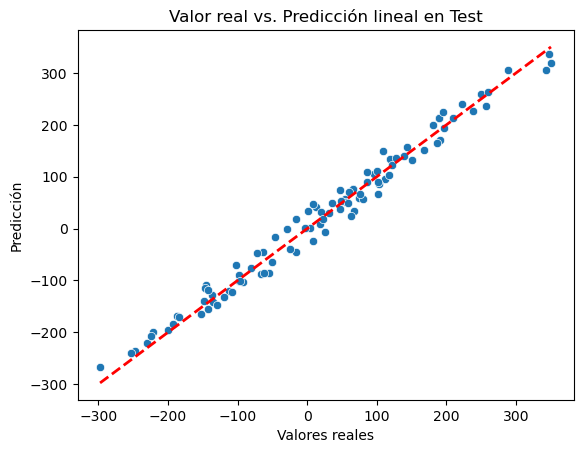

In [11]:
sns.scatterplot(x=y_test,y=y_pred)
min_val = min(y_test.min(), y_pred.min())  # Valor mínimo para la diagonal
max_val = max(y_test.max(), y_pred.max())  # Valor máximo para la diagonal
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Línea ideal (y=x)")
plt.xlabel('Valores reales')
plt.ylabel('Predicción')
plt.title('Valor real vs. Predicción lineal en Test')
plt.savefig(os.path.join(images_path, "GD_error_1"))
plt.show

## Caso Comercio en Internet

Veamos el caso de las ventas de un determinado comercio en internet [enlace en kaggle](https://www.kaggle.com/iyadavvaibhav/ecommerce-customer-device-usage/notebooks).
Los datos incluyen información de la actividad de los clientes de una tienda. 

Los clientes tienen sesiones presenciales con un asesor comercial y posteriormente desde la aplicación de compras hacen pedidos de los productos que les interesan.La información incluye:
* `Avg. Session Length`: Promedio de duración de las sesiones de asesoramiento de estilo en la tienda.
* `Time on App`: Tiempo promedio pasado en la aplicación en minutos.
* `Time on Website`: Tiempo promedio pasado en el sitio web en minutos.
* `Length of Membership`: Cuantos años lleva el cliente como miembro de esa aplicación.
* `Yearly Amount Spent`:  Gasto anual del cliente.

Vamos a hacer un modelo lineal que nos permita predecir el gasto anual a partir del resto de variables.

### Cargamos los datos

In [12]:
customers = pd.read_csv('./Archivos/Ecommerce_Customers.csv')
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### Análisis de datos
Dividimos las columnas de la tabla entre las variables de entrada predictoras y la variable a predecir.

In [13]:
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']].values
y = customers['Yearly Amount Spent'].values

### División en Train/test

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6543)

### Cálculo del vector de coeficientes $\Theta$

Empleo los dos métodos vistos. 
* Ecuaciones Normales.
* Descenso de Gradiente. (Juega con la tasa de aprendizaje y el número de iteraciones)

In [16]:
Theta_normal = normal_equation(X_train,y_train)
print('Normal:', Theta_normal)

Theta_gradient = batch_gradient_descent(X_train, y_train, learning_rate=0.0001, n_epochs=100000 )
print('GD_sin normalizar:', Theta_gradient)

Theta_gradient_std = batch_gradient_descent_std(X_train, y_train, learning_rate=0.1, n_epochs=100 )
print('GD_con normalizado:', Theta_gradient_std)

Normal: [-1.05433827e+03  2.57823340e+01  3.86795081e+01  4.65367326e-01
  6.17673324e+01]
GD_sin normalizar: [ -7.9154375   11.82996352  35.11663792 -14.07220879  60.75418425]
GD_con normalizado: [-1.05433827e+03  2.57823340e+01  3.86795081e+01  4.65367326e-01
  6.17673324e+01]


### Predicción sobre los datos de test.

* Cálculo del error MSE para ambos métodos: ecuación normal y descenso de gradiente en los datos de test.
* Gráfica de las predicciones frente a los valores reales de test.

In [17]:
#***** TU CODIGO AQUI ********* (1 línea)
y_pred = predicted(X_test, Theta_normal)
#***** TU CODIGO AQUI ********* 
print(y_test.shape[0])
# Calculo del error

#***** TU CODIGO AQUI ********* (1 línea)
mse_test = sum((y_pred-y_test)**2)/(y_pred.shape[0])
#***** TU CODIGO AQUI ********* 
print('MSE normal: ',mse_test)

#***** TU CODIGO AQUI ********* (1 línea)
y_pred = predicted(X_test, Theta_gradient)
#***** TU CODIGO AQUI ********* 
print(y_test.shape[0])
# Calculo del error

#***** TU CODIGO AQUI ********* (1 línea)
mse_test = sum((y_pred-y_test)**2)/(y_pred.shape[0])
#***** TU CODIGO AQUI ********* 
print('MSE GD: ',mse_test)

100
MSE normal:  89.87835637671016
100
MSE GD:  458.9451479958662
